# Linear Regression Baseline Model

This notebook trains a simple linear regression model as a baselin 

The purpose is not to create the final forecasting model, but to provide a simpler comparison model before using the Temporal Fusion Transformer.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

C:\Users\tuvap\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\tuvap\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## Load modelling dataset

The model dataset from the feature engineering notebook is loaded, and already contains calendar variables, lag features, rolling statistics and selected categorical variables that is needed here.

In [4]:
data = pd.read_csv("model_dataset.csv")

print(data.shape)
data.head()

(579105, 16)


,Kundenr,Dato,time_idx,Leveringstid (min),month,week,Planlagt leveringstid (min),Antall leveranser,Vekt (kg),lag_1,lag_7,rolling_mean_7,rolling_std_7,dayOfWeek,Fylke,Drivstofftype
0,201966.0,2020-02-18,0,31.816667,2,8,11.000000,1.0,240.0,12.566667,11.583333,9.433333,2.553647,1,Rogaland,GASS
1,201966.0,2020-02-19,1,14.416667,2,8,11.000000,1.0,240.0,31.816667,9.933333,12.323810,8.916593,2,Rogaland,GASS
2,201966.0,2020-02-20,2,5.600000,2,8,11.166667,1.0,12.0,14.416667,5.683333,12.964286,8.877199,3,Rogaland,GASS
3,201966.0,2020-02-24,3,21.816667,2,9,10.200000,1.0,240.0,5.600000,6.316667,12.952381,8.888639,0,Rogaland,GASS
4,201966.0,2020-02-26,4,10.100000,2,9,11.000000,1.0,240.0,21.816667,9.783333,15.166667,8.890715,2,Rogaland,GASS


## Define target and input features

The next step is to define the target variable and input features for the baseline model. The target variable is actual delivery time in minutes. The input features include calendar variables, planned delivery information, historical lag features, rolling statistics, and selected categorical variables. Similar feature groups are used later in the TFT model, which makes this comparison more relevant.

In [5]:
data["Dato"] = pd.to_datetime(data["Dato"], errors="coerce")
targetColumn = "Leveringstid (min)"

featureColumns = [
    "month",
    "week",
    "Planlagt leveringstid (min)",
    "Antall leveranser",
    "Vekt (kg)",
    "lag_1",
    "lag_7",
    "rolling_mean_7",
    "rolling_std_7",
    "dayOfWeek",
    "Fylke",
    "Drivstofftype"]

X = data[featureColumns].copy()
y = data[targetColumn]

## Separate numerical and categorical features

The input features are separated into numerical and categorical variables. This is needed because the baseline linear regression model can use numerical values directly, while categorical variables need to be encoded first.

In [6]:
categoryColumns = X.select_dtypes(include=["object", "category"]).columns.tolist()
numberColumns = X.select_dtypes(include=["number"]).columns.tolist()

print("Categorical:", categoryColumns)
print("Numeric:", numberColumns)

Categorical: ['Fylke', 'Drivstofftype']
Numeric: ['month', 'week', 'Planlagt leveringstid (min)', 'Antall leveranser', 'Vekt (kg)', 'lag_1', 'lag_7', 'rolling_mean_7', 'rolling_std_7', 'dayOfWeek']


C:\Users\tuvap\AppData\Local\Temp\ipykernel_87796\181721703.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoryColumns = X.select_dtypes(include=["object", "category"]).columns.tolist()


## Create preprocessing pipeline

Numerical missing values are replaced with the median value. Categorical variables are converted using one-hot encoding. Unknown categories are ignored, so the model can also handle new categories in the test data. These steps are combined in a ColumnTransformer so both numerical and categorical features are prepared correctly before training the baseline model.

In [7]:
numberPipe = SimpleImputer(strategy="median")
categoryPipe = OneHotEncoder(handle_unknown="ignore")

preprocess = ColumnTransformer([("numbers", numberPipe, numberColumns), ("categories", categoryPipe, categoryColumns)])

## Split data by time

The dataset is split using a time-based cutoff. The first 80 percent of observations by date are used for training, while the remaining 20 percent are used for testing. This is used instead of a random split so the model is trained on earlier data and tested on later data, which better matches a real forecasting situation.

In [8]:
cutoffDate = data["Dato"].quantile(0.8)

trainData = data[data["Dato"] <= cutoffDate].copy()
testData = data[data["Dato"] > cutoffDate].copy()

Xtrain = trainData[featureColumns]
yTrain = trainData[targetColumn]

Xtest = testData[featureColumns]
yTest = testData[targetColumn]

print("Train:", Xtrain.shape)
print("Test:", Xtest.shape)
print("Cutoff:", cutoffDate)

Train: (463552, 12)
Test: (115553, 12)
Cutoff: 2024-07-23 00:00:00


## Train linear regression model


A pipeline is created with preprocessing followed by a linear regression model. This combines the data preparation steps with the model in one workflow. The figure below is an automatic overview of the pipeline structure, showing how the data moves through preprocessing before reaching the regression model.

In [9]:
# https://www.geeksforgeeks.org/machine-learning/linear-regression-python-implementation/
# https://scikit-learn.org/stable/modules/linear_model.html

model = Pipeline([("prep", preprocess), ("model", LinearRegression())])
model.fit(Xtrain, yTrain)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numbers', ...), ('categories', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Evaluate baseline accuracy

As seen, this baseline model achieved an MAE of 6.76 minutes and an RMSE of 11.81 minutes. This means the average prediction error is relatively moderate, but some larger errors are still present as expected.

In [10]:
yPred = model.predict(Xtest)

mae = mean_absolute_error(yTest, yPred)
rmse = np.sqrt(mean_squared_error(yTest, yPred))
mape = (np.abs(yPred - yTest) / yTest.replace(0, np.nan)).mean() * 100

print("Linear regression:")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

Linear regression:
MAE: 6.76
RMSE: 11.81
MAPE: 172.51%


## Plot predicted versus actual values

This scatter plot is used to compare predicted delivery time with actual delivery time. Points closer to the diagonal line represent more accurate predictions. This gives a simple visual check of how well the linear regression baseline captures the overall delivery time pattern.

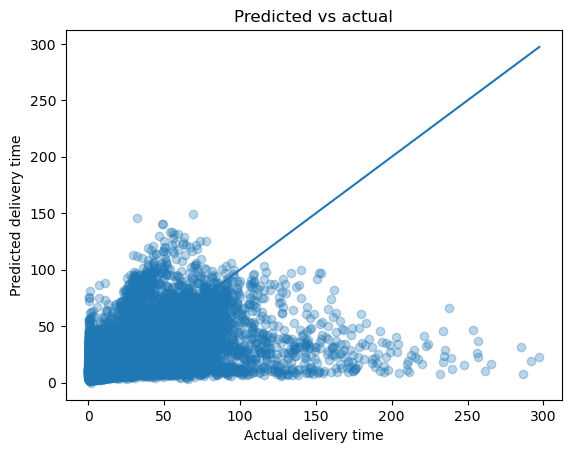

In [11]:
plt.figure()
plt.scatter(yTest, yPred, alpha=0.3)
plt.plot([yTest.min(), yTest.max()], [yTest.min(), yTest.max()])

plt.xlabel("Actual delivery time")
plt.ylabel("Predicted delivery time")
plt.title("Predicted vs actual")

plt.show()

## Zoom in on normal delivery times

The same plot is shown here but zoomed in to better inpect.

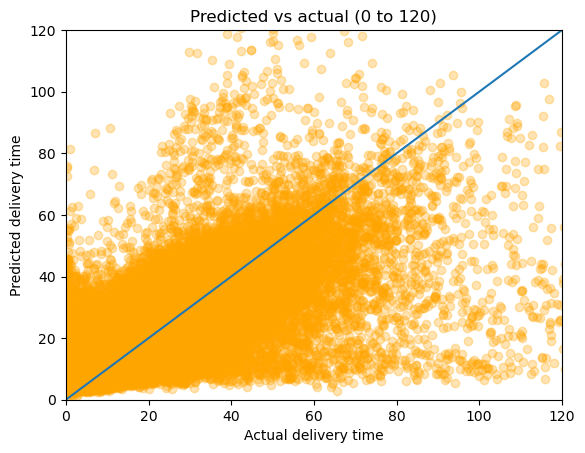

In [12]:
plt.figure()
plt.scatter(yTest, yPred, alpha=0.3, color = "orange")
plt.plot([yTest.min(), yTest.max()], [yTest.min(), yTest.max()])

plt.xlim(0, 120)
plt.ylim(0, 120)

plt.xlabel("Actual delivery time")
plt.ylabel("Predicted delivery time")
plt.title("Predicted vs actual (0 to 120)")

plt.show()

## Plot error distribution

Prediction errors are calculated as predicted delivery time minus actual delivery time. Most errors are close to zero, which means the baseline model often gives good predictions. The distribution is centred, but some larger positive and negative errors are still present. This shows that the model captures the general pattern, but sometimes makes larger mistakes.

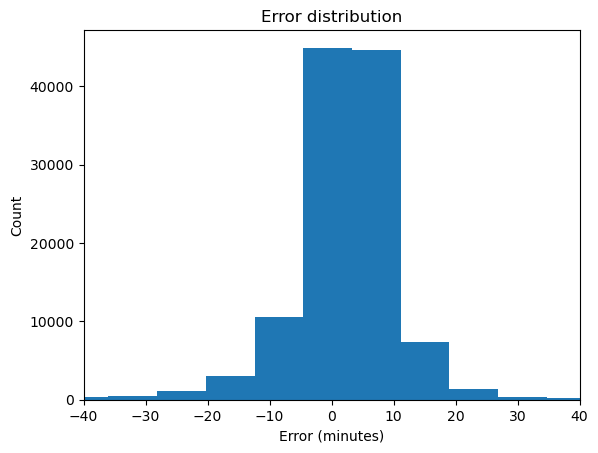

In [16]:
errors = yPred - yTest

plt.figure()
plt.hist(errors, bins=50)
plt.xlim(-40, 40)
plt.xlabel("Error (minutes)")
plt.ylabel("Count")
plt.title("Error distribution")

plt.show()

In [17]:
import json

with open("4.2 linear regression model.ipynb", "r", encoding="utf-8") as f:
    nb = json.load(f)

for i, cell in enumerate(nb["cells"]):
    if cell["cell_type"] == "code":
        print("\n" + "="*70)
        print(f"CELL {i}")
        print("="*70)
        print("".join(cell["source"]))



CELL 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

CELL 3
data = pd.read_csv("model_dataset.csv")

print(data.shape)
data.head()

CELL 5
data["Dato"] = pd.to_datetime(data["Dato"], errors="coerce")
targetColumn = "Leveringstid (min)"

featureColumns = [
    "month",
    "week",
    "Planlagt leveringstid (min)",
    "Antall leveranser",
    "Vekt (kg)",
    "lag_1",
    "lag_7",
    "rolling_mean_7",
    "rolling_std_7",
    "dayOfWeek",
    "Fylke",
    "Drivstofftype"]

X = data[featureColumns].copy()
y = data[targetColumn]

CELL 7
categoryColumns = X.select_dtypes(include=["object", "category"]).columns.tolist()
numberColumns = X.select_dtypes(include=["number"]).colum